In [4]:
%cd ..

/Users/macos/Uni/1st_year/IntroDS/mini_project


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Open XLS file

In [2]:
path = "global-data-on-sustainable-energy.xlsx"

In [6]:
df = pd.read_excel(path)

In [7]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60.0,652230.0,33.93911,67.709953


In [8]:
trg_name = "Electricity from renewables (TWh)"

df[trg_name]

0       0.31
1       0.50
2       0.56
3       0.63
4       0.56
        ... 
3644    3.32
3645    4.30
3646    5.46
3647    4.58
3648    4.19
Name: Electricity from renewables (TWh), Length: 3649, dtype: float64

In [10]:
df['Entity'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia',
       'Cameroon', 'Canada', 'Cayman Islands', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'French Guiana', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau',
       'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Icelan

In [11]:
df_af = df[df['Entity'] == 'Afghanistan']

df_af.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60.0,652230.0,33.93911,67.709953


In [14]:
s = df_af[[trg_name, 'Year']].set_index('Year')
s.head()

,Electricity from renewables (TWh)
Year,
2000,0.31
2001,0.50
2002,0.56
2003,0.63
2004,0.56


<Axes: xlabel='Year'>

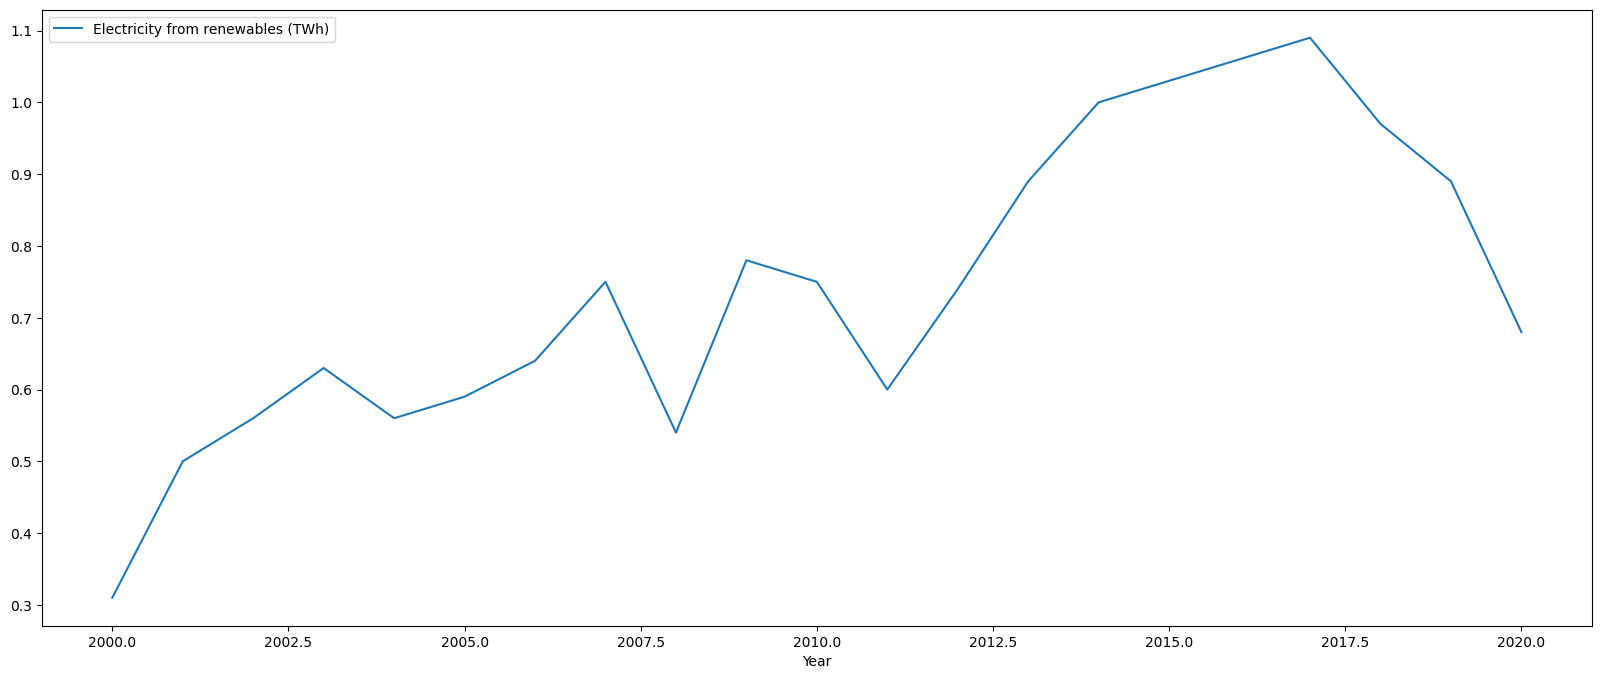

In [15]:
s.plot(kind='line', figsize=(20, 8))

## Some EDAs and tests

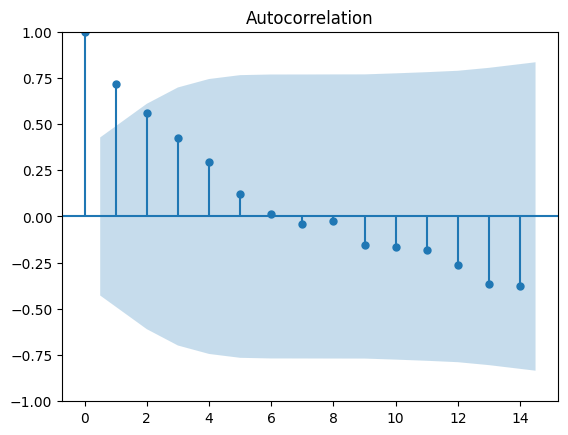

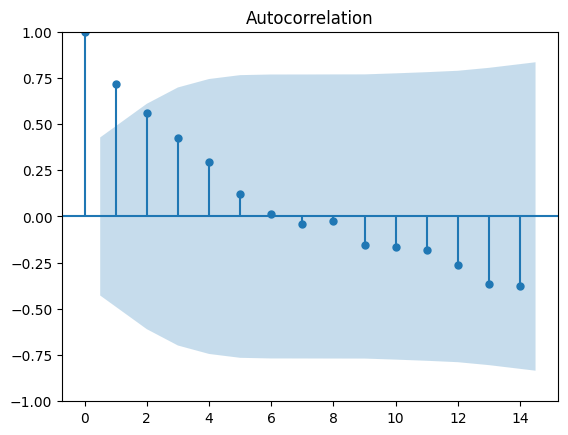

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(s)

In [18]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(s, order=(1, 1, 2))
model = arima.fit()

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [23]:
model.forecast(10)

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


21    0.665121
22    0.609760
23    0.582574
24    0.569224
25    0.562668
26    0.559449
27    0.557868
28    0.557091
29    0.556710
30    0.556523
Name: predicted_mean, dtype: float64

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

<Axes: xlabel='Year'>

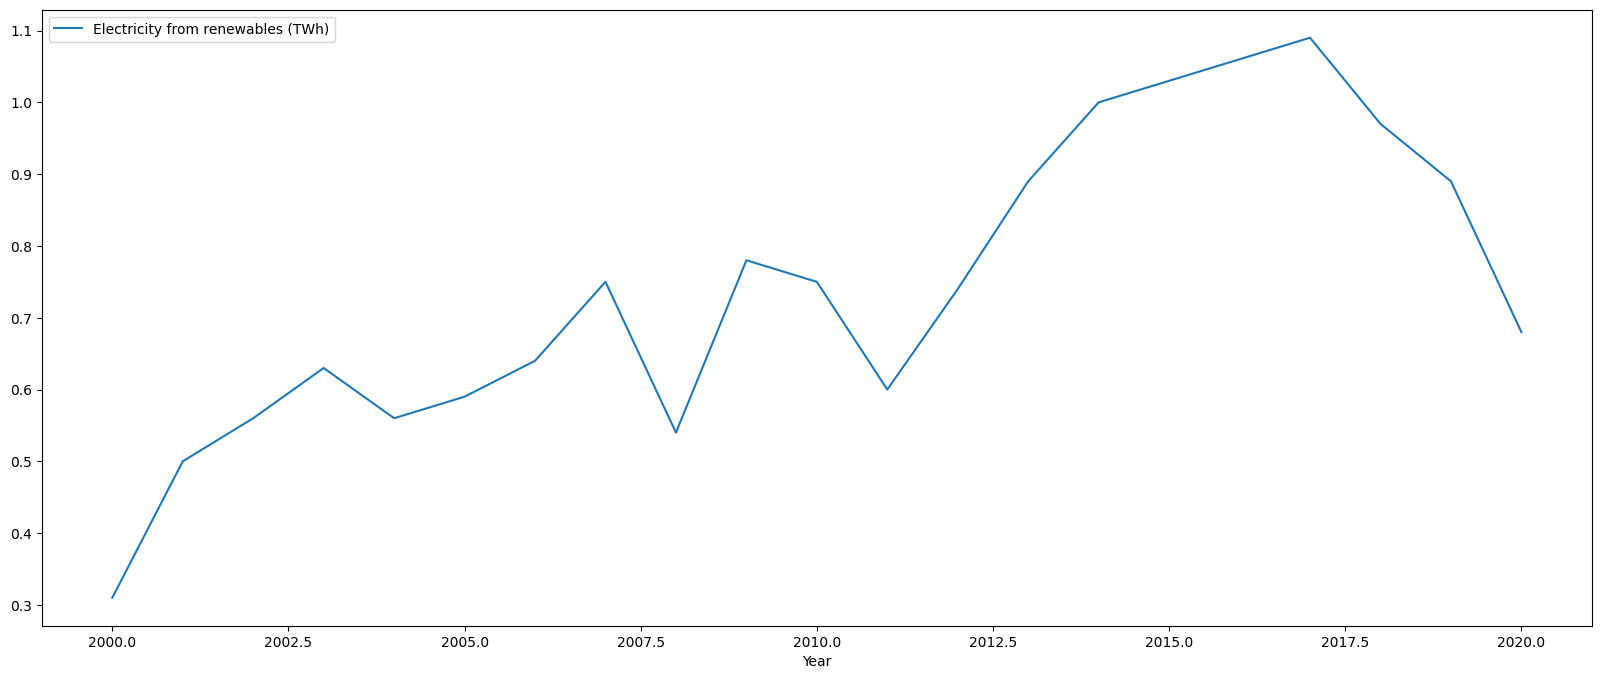

In [25]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111)

sns.lineplot(s, color='blue', ax=ax)

In [28]:
pred = pd.Series(model.forecast(10).copy(), index=range(2021,2030))
pred

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2021   NaN
2022   NaN
2023   NaN
2024   NaN
2025   NaN
2026   NaN
2027   NaN
2028   NaN
2029   NaN
Name: predicted_mean, dtype: float64

In [33]:
pred = model.forecast(10)


/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


21    0.665121
22    0.609760
23    0.582574
24    0.569224
25    0.562668
26    0.559449
27    0.557868
28    0.557091
29    0.556710
30    0.556523
Name: predicted_mean, dtype: float64

In [36]:
sns.lineplot(pred, color='red', ax=ax)

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

<Axes: xlabel='Year'>

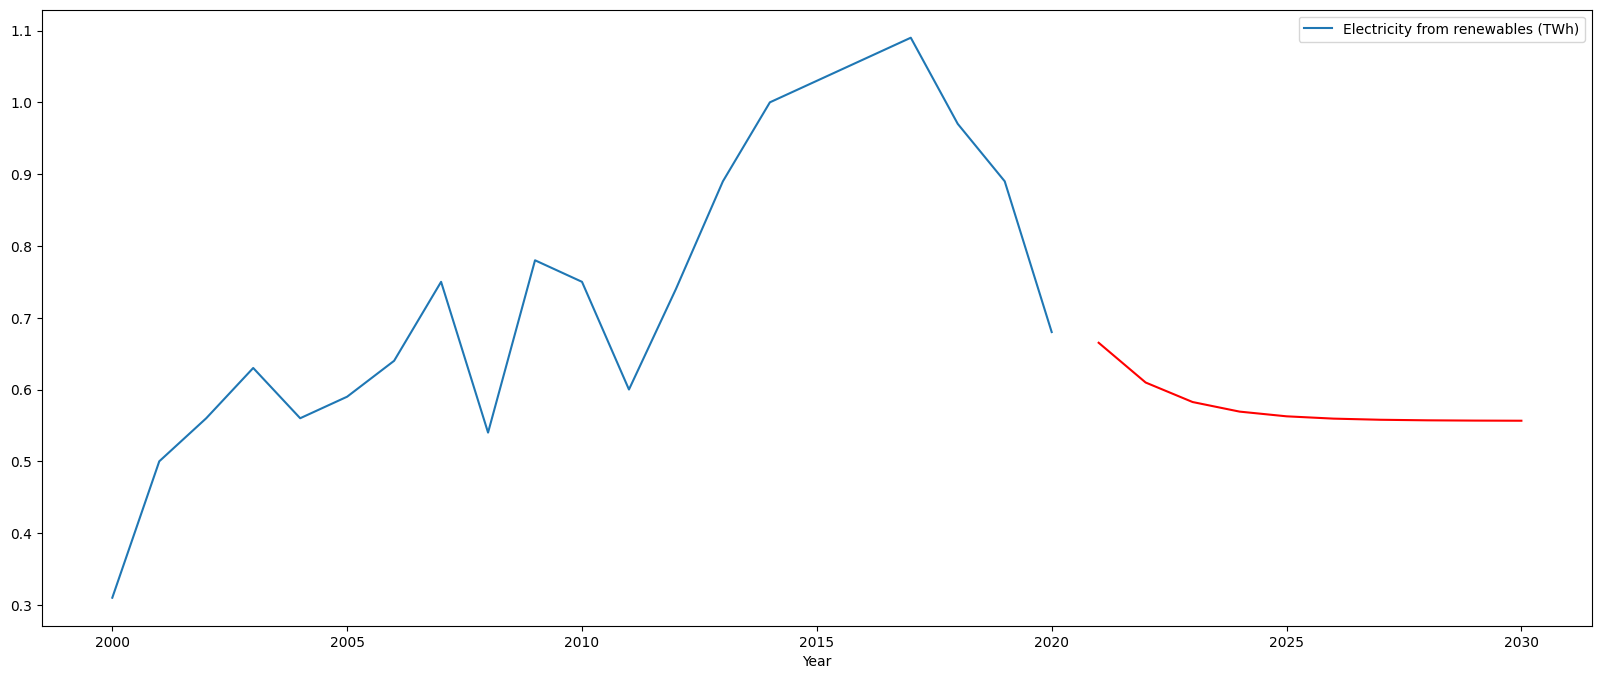

In [37]:
fig

## Detrending: Differencing

In [38]:
s

,Electricity from renewables (TWh)
Year,
2000,0.31
2001,0.50
2002,0.56
2003,0.63
2004,0.56
2005,0.59
2006,0.64
2007,0.75
2008,0.54


In [41]:
s[:-1]

,Electricity from renewables (TWh)
Year,
2000,0.31
2001,0.50
2002,0.56
2003,0.63
2004,0.56
2005,0.59
2006,0.64
2007,0.75
2008,0.54


In [49]:
s_diff = pd.Series((s[1:].values - s[:-1].values).squeeze(), index=range(2001, 2021))
s_diff

2001    0.19
2002    0.06
2003    0.07
2004   -0.07
2005    0.03
2006    0.05
2007    0.11
2008   -0.21
2009    0.24
2010   -0.03
2011   -0.15
2012    0.14
2013    0.15
2014    0.11
2015    0.03
2016    0.03
2017    0.03
2018   -0.12
2019   -0.08
2020   -0.21
dtype: float64

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

<Axes: xlabel='Year'>

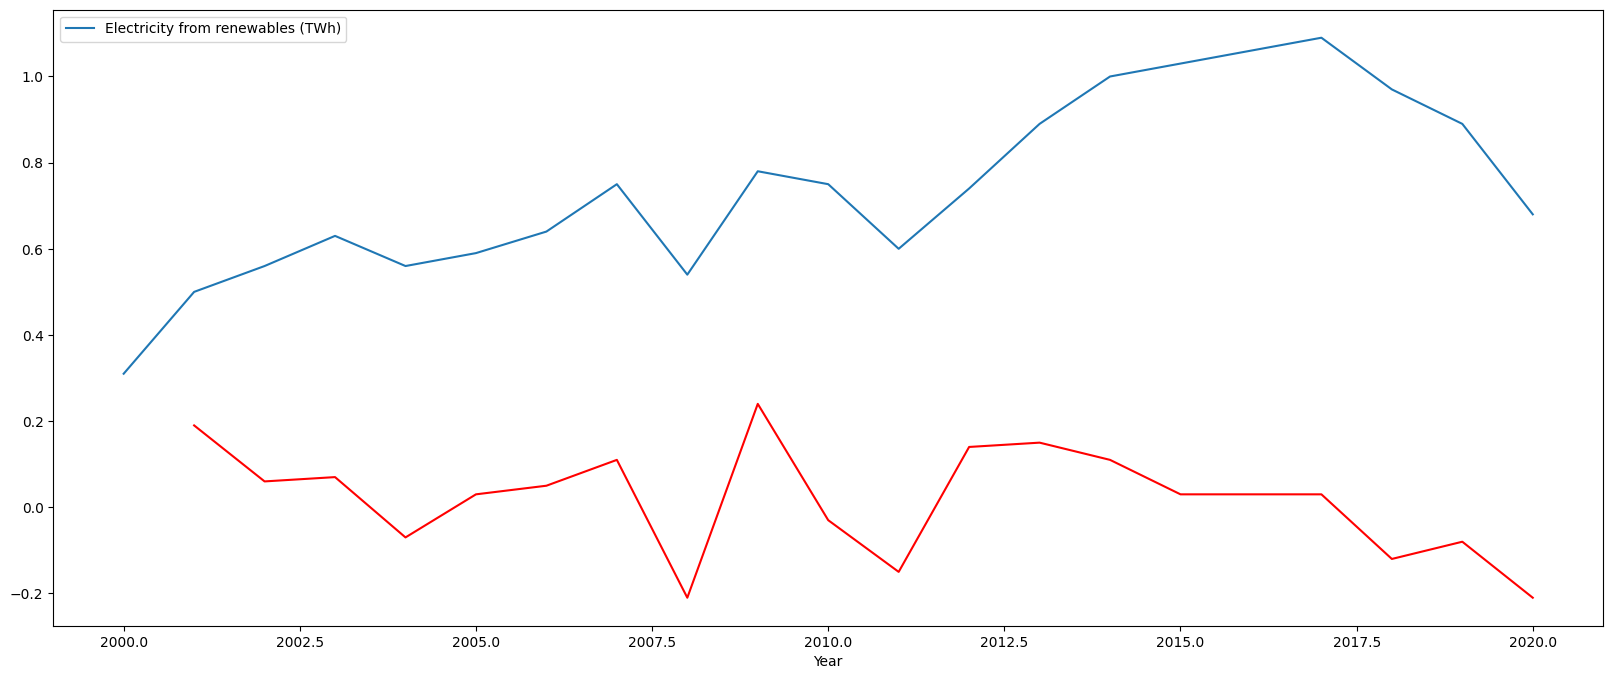

In [50]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(111)

sns.lineplot(s, color='green', ax=ax)
sns.lineplot(s_diff, color='red', ax=ax)

In [51]:
arima1 = ARIMA(s, order=(1, 1, 2))
model1 = arima1.fit()

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [53]:
pred_1 = model1.forecast(10)
pred_1

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


21    0.665121
22    0.609760
23    0.582574
24    0.569224
25    0.562668
26    0.559449
27    0.557868
28    0.557091
29    0.556710
30    0.556523
Name: predicted_mean, dtype: float64

In [56]:
## Reset the index (year)
pred_1 = pd.Series(pred_1.values, index = range(2021, 2031))
pred_1

2021    0.665121
2022    0.609760
2023    0.582574
2024    0.569224
2025    0.562668
2026    0.559449
2027    0.557868
2028    0.557091
2029    0.556710
2030    0.556523
dtype: float64

In [52]:
arima2 = ARIMA(s_diff, order=(1, 1, 2))
model2 = arima2.fit()

In [54]:
pred_2 = model2.forecast(10)
pred_2

2021   -0.124483
2022   -0.173430
2023   -0.179271
2024   -0.179968
2025   -0.180052
2026   -0.180062
2027   -0.180063
2028   -0.180063
2029   -0.180063
2030   -0.180063
Name: predicted_mean, dtype: float64

## Un-differencing

In [57]:
s_final_differenced = pd.concat((s_diff, pred_2))
s_final_differenced

2001    0.190000
2002    0.060000
2003    0.070000
2004   -0.070000
2005    0.030000
2006    0.050000
2007    0.110000
2008   -0.210000
2009    0.240000
2010   -0.030000
2011   -0.150000
2012    0.140000
2013    0.150000
2014    0.110000
2015    0.030000
2016    0.030000
2017    0.030000
2018   -0.120000
2019   -0.080000
2020   -0.210000
2021   -0.124483
2022   -0.173430
2023   -0.179271
2024   -0.179968
2025   -0.180052
2026   -0.180062
2027   -0.180063
2028   -0.180063
2029   -0.180063
2030   -0.180063
dtype: float64

In [71]:
s_final = [s.iloc[0].item()]
for i in range(1, len(s_final_differenced)):
    s_final.append(s_final[i - 1] + s_final_differenced.iloc[i - 1])
s_final

[0.31,
 0.5,
 0.56,
 0.63,
 0.56,
 0.59,
 0.64,
 0.75,
 0.54,
 0.78,
 0.75,
 0.6,
 0.74,
 0.89,
 1.0,
 1.03,
 1.06,
 1.09,
 0.97,
 0.89,
 0.68,
 0.5555171414624246,
 0.38208743925154554,
 0.20281612196583856,
 0.022847630682351044,
 -0.15720406560128716,
 -0.3372656920774915,
 -0.5173285036834865,
 -0.6973914567301042,
 -0.877454426657109]

In [77]:
s_final = pd.Series(s_final, index=range(2000, 2030))
s_final

2000    0.310000
2001    0.500000
2002    0.560000
2003    0.630000
2004    0.560000
2005    0.590000
2006    0.640000
2007    0.750000
2008    0.540000
2009    0.780000
2010    0.750000
2011    0.600000
2012    0.740000
2013    0.890000
2014    1.000000
2015    1.030000
2016    1.060000
2017    1.090000
2018    0.970000
2019    0.890000
2020    0.680000
2021    0.555517
2022    0.382087
2023    0.202816
2024    0.022848
2025   -0.157204
2026   -0.337266
2027   -0.517329
2028   -0.697391
2029   -0.877454
dtype: float64

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

<Axes: xlabel='Year'>

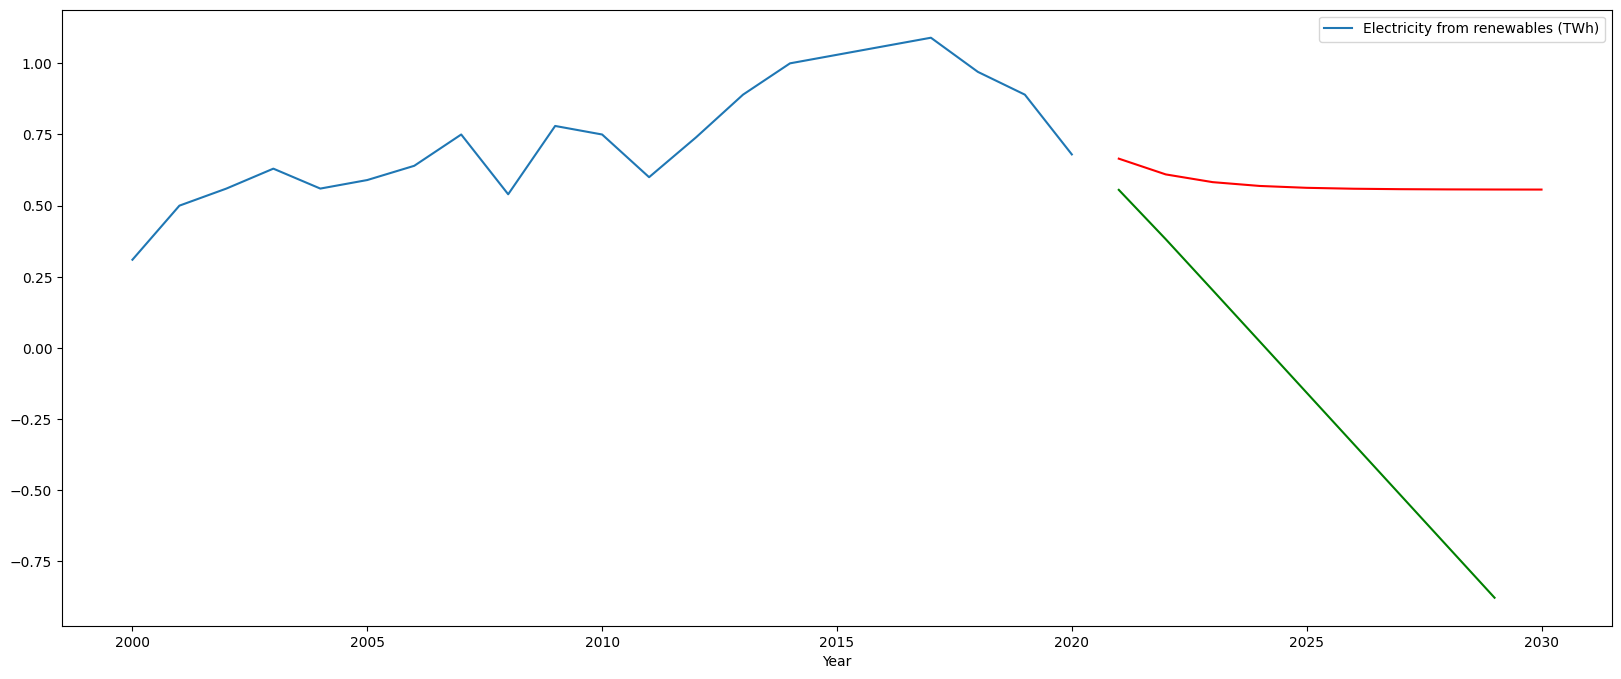

In [80]:
## Plot
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(111)

sns.lineplot(s, color='blue', ax=ax)
sns.lineplot(pred_1, color='red', ax=ax)
sns.lineplot(s_final[-9:], color='green', ax=ax)

## Find p, q for ARIMA model

In [92]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame: 
 
    results = [] 
    print(order_list)
    for order in tqdm_notebook(order_list): 
        # try:
        model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False) 
        # except:
        #     continue
        
        aic = model.aic 
        results.append([order, aic]) 
        
        result_df = pd.DataFrame(results) 
        result_df.columns = ['(p,q)', 'AIC'] 
        
        #Sort in ascending order, lower AIC is better
        result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True) 
    
    return result_df

In [ ]:
a

In [94]:
from itertools import product
ps = range(0, 10, 1) 
qs = range(0, 10, 1) 
order_list = list(product(ps, qs)) 

optimize_ARMA(s_diff, order_list) 

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (7, 9), (8, 0), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8), (8, 9), (9, 0), (9, 1), (9, 2), (9, 3), (9, 4), (9, 5), (9, 6), (9, 7), (9, 8), (9, 9)]


/var/folders/pr/8dv_cj95295bxt_hr8hzrmk40000gn/T/ipykernel_94849/385964744.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances wi

,"(p,q)",AIC
0,"(0, 0)",-24.458557
1,"(1, 0)",-22.526729
2,"(0, 1)",-22.520103
3,"(0, 2)",-20.584891
4,"(2, 0)",-20.557625
...,...,...
95,"(8, 8)",1.092717
96,"(9, 7)",1.178467
97,"(9, 8)",2.995011
98,"(8, 9)",4.135103


In [ ]:
## So, we choose p = 0 and q = 0
arima2 = ARIMA(s_diff, order=(0, 1, 0))